## Titanic Dataset Implementation

Name: Kalaiarashi S B

This project demonstrates about the decision tree classifier using titanic dataset predicting how many people survived

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading dataset

In [46]:
df=pd.read_csv("Titanic.csv")

In [47]:
x=df[['sex','age','class']]
y=df[['survived']]

## Handling missing values

In [49]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
df['age']=imputer.fit_transform(df[['age']])

In [30]:
df.isnull().sum()

,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0
alone,0
survived,0


In [50]:
df=df.dropna()
df.isnull().sum()

,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0
alone,0
survived,0


## Encoding categorical values

In [51]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
le2=LabelEncoder()
df['sex']=le1.fit_transform(df['sex'])
df['class']=le2.fit_transform(df['class'])

In [52]:
print(df['class'])

0      2
1      0
2      2
3      0
4      2
      ..
886    1
887    0
888    2
889    0
890    2
Name: class, Length: 889, dtype: int64


In [55]:
x=df[['sex','age','class']]
y=df[['survived']]

## Spliting training test dataset

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
print(x_train)

     sex        age  class
885    0  39.000000      2
78     1   0.830000      1
834    1  18.000000      2
218    0  32.000000      0
875    0  15.000000      2
..   ...        ...    ...
354    1  29.699118      2
826    1  29.699118      2
672    1  70.000000      1
458    0  50.000000      1
715    1  19.000000      2

[711 rows x 3 columns]


## Training dataset

In [59]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(max_depth=3)
classifier.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

## Visualization

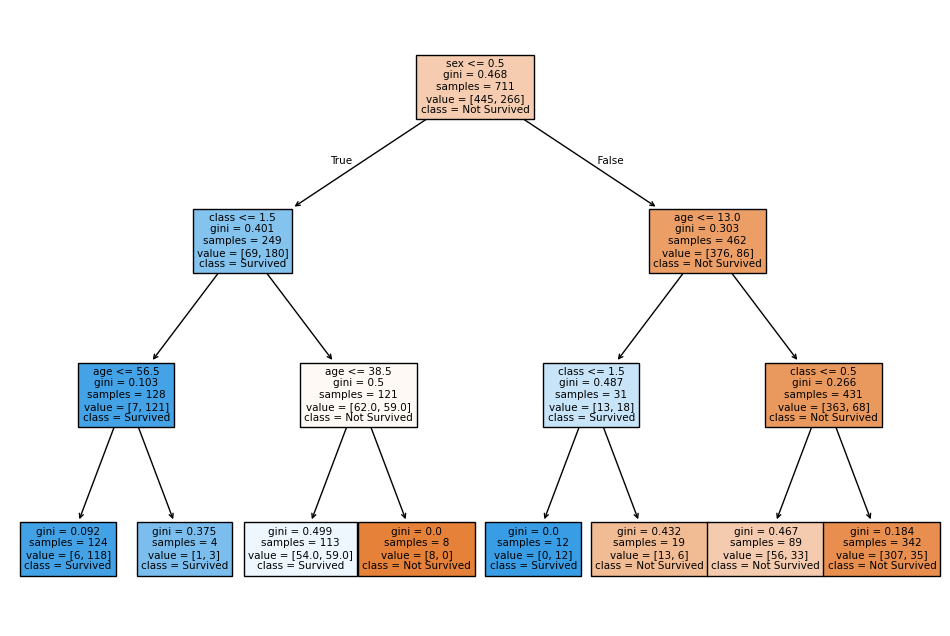

In [60]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

tree.plot_tree(
    classifier,
    feature_names=['sex','age','class'],
    class_names=['Not Survived','Survived'],
    filled=True
)

plt.show()

## Prediction of dataset

In [64]:
y_pred=classifier.predict(x_test)
print(y_pred)

[0 0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1
 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0
 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0
 1 0 0 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0]


In [67]:
y=classifier.predict([[0,35,1]])
print(y)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Accuracy

In [68]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8146067415730337


## Key insights


1.Female passengers had a significantly higher survival rate than male passengers.

2.First and second class passengers survived more compared to third class passengers.

3.Younger passengers, especially children, had better survival chances.

4.Sex(male,female) was identified as the most important feature for predicting survival.

5.Passenger class and age also played important roles in survival prediction.